Skewed data and sclaing

Demo 2 common preprocesssing problems:
1. Skewed distribution
2. Features on different scales

1. Imprts

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

np.random.seed(42)

2. Generate example data
we create
age - approximately normal distirbution
income - strongly right-skewed distribution
spending_score - smaller scale numeric featrue

In [ ]:
n = 500

df = pd.DataFrame( {
    "age": np.random.normal(38, 10, n).round(),
    "income": np.random.lognormal(mean=10, sigma=0.7, size=n),
    "spending_score": np.random.normal(50, 12, n)
})

df.head(10)

,age,income,spending_score
0,43.0,42121.950918,66.792265
1,37.0,83833.808542,61.095604
2,44.0,8275.070322,50.715564
3,53.0,32665.621242,42.236759
4,36.0,13968.362105,58.378680
5,36.0,15662.306290,54.721825
6,54.0,14549.679619,60.742319
7,46.0,12030.573270,57.622062
8,33.0,22787.448058,62.594633
9,43.0,12312.064552,43.577177


3. Inspect the data

In [ ]:
df.describe()

,age,income,spending_score
count,500.0000,500.000000,500.000000
mean,38.0960,28495.329866,51.301814
std,9.8377,21696.998905,12.122956
min,6.0000,3334.837895,15.244935
25%,31.0000,14520.285428,42.770845
50%,38.0000,22470.803668,51.437670
75%,44.0000,34747.760587,59.056860
max,77.0000,139060.927774,81.220197


array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'income'}>],
       [<Axes: title={'center': 'spending_score'}>, <Axes: >]],
      dtype=object)

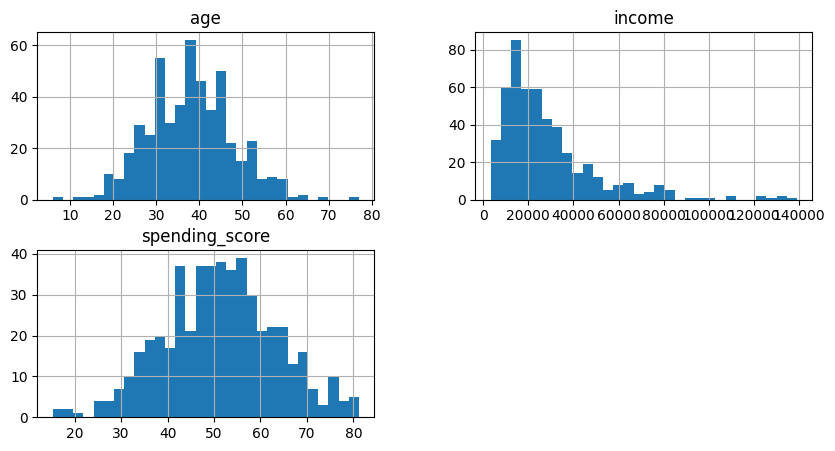

In [ ]:
df.hist(figsize=(10, 5), bins=30)
# plt.tight_layout()
# plt.show()

4. Detect skewness
near 0 - symetric distribution
> 1 - strongly right skewed
< -1 - strongly left skewed

In [ ]:
df.skew(numeric_only=True).sort_values(ascending=False)

income            2.090376
age               0.191031
spending_score   -0.036397
dtype: float64

Income is strongly right-skewed.

This is common for :
- salries
- house prices
- transaction values
- customer spending

## 5. Fix skewness using log trasfromation  
apply: log(1 + x)  
This compressed large vlues and produces a more balanced distribution


In [ ]:
df["income_log"] = np.log1p(df["income"])
df[["income", "income_log"]].hist(figsize=(10, 5), bins=30)

TypeError: loop of ufunc does not support argument 0 of type str which has no callable log1p method

## 6. Scaling / normalozation
The features are on very different scalers:
- age - around 20 - 60
- income thousands
- spending_score - around 0-100

Some ML models are sensitive to scale&  
- Logistic Regression
- KNN
- Neural Networks

In [ ]:
df.columns

Index(['age', 'income', 'spending_score', 'income_log'], dtype='str')

In [ ]:
features = df[["age", "income_log", "spending_score"]]
features.describe()

,age,income_log,spending_score
count,500.0000,500.000000,500.000000
mean,38.0960,10.022334,51.301814
std,9.8377,0.684561,12.122956
min,6.0000,8.112479,15.244935
25%,31.0000,9.583365,42.770845
50%,38.0000,10.020017,51.437670
75%,44.0000,10.455898,59.056860
max,77.0000,11.842675,81.220197


We apply StandardScaler.  
After scaling:  
- mean ~ 0
- standard deviation ~ 1

In [ ]:
scaler = StandardScaler()

scaled_array = scaler.fit_transform(features)

features_scaled = pd.DataFrame(
    scaled_array, 
    columns=[col + "_scled" for col in features.columns]
    )

features_scaled.describe().round(2)

,age_scled,income_log_scled,spending_score_scled
count,500.00,500.00,500.00
mean,0.00,-0.00,0.00
std,1.00,1.00,1.00
min,-3.27,-2.79,-2.98
25%,-0.72,-0.64,-0.70
50%,-0.01,-0.00,0.01
75%,0.60,0.63,0.64
max,3.96,2.66,2.47


array([[<Axes: title={'center': 'age_scled'}>,
        <Axes: title={'center': 'income_log_scled'}>],
       [<Axes: title={'center': 'spending_score_scled'}>, <Axes: >]],
      dtype=object)

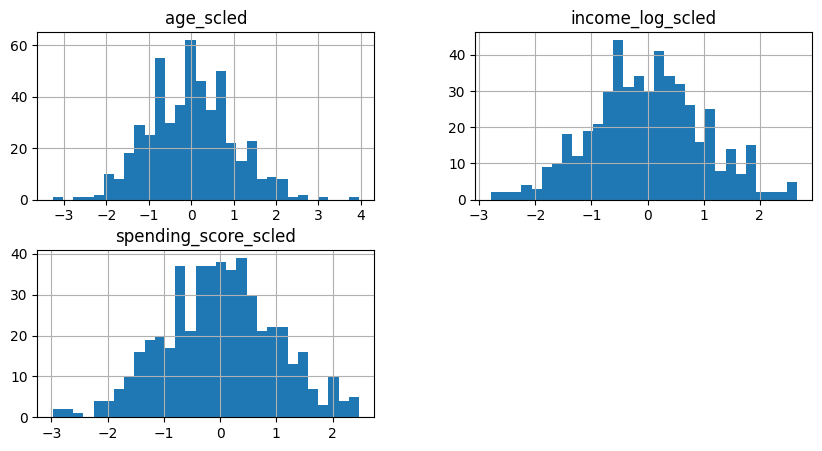

In [ ]:
features_scaled.hist(figsize=(10, 5), bins=30)

In [ ]:
final_df = features_scaled.copy()

final_df.head(10)

,age_scled,income_log_scled,spending_score_scled
0,0.498990,0.915391,1.279058
1,-0.111520,1.921795,0.808681
2,0.600741,-1.464024,-0.048407
3,1.516505,0.543629,-0.748508
4,-0.213271,-0.698537,0.584342
5,-0.213271,-0.531175,0.282393
6,1.618257,-0.638919,0.779509
7,0.804244,-0.916898,0.521868
8,-0.518526,0.017072,0.932456
9,0.498990,-0.883081,-0.637829


# Summary
We demonstrated two common preprocessing techniques:
1. Handling skewed data  
- Problems: strongly right-skewed income distribution
- Solution: log transformation
2. Feature scaling
- Problem: features on different numeric scales
- Solution: standartization with StandardScaler  

These preprocessin stps help prepare data for machine learning models


## 10. Reflection
Write a short summary:
- What data quality issues did you find?
- How did you handle missing values?
- Which preprocessing steps did you apply?
- How did class imbalance affect the task?
- What changed after preprocessing?